# Pairs Trading — Complete GGR (2006) Replication on US Equities
## Gatev, Goetzmann & Rouwenhorst (2006)

**EC581 Algorithmic Trading — Bogazici University**

Full replication of all tables and analyses from *Pairs Trading: Performance of a Relative-Value Arbitrage Rule* (GGR, 2006).

**Tables replicated:** Table 1 (Panel A + B), Table 2 (trading stats), Table 3 (sector-neutral), Table 4 (risk regression), Table 5 (VAR), Figure 2 (monthly performance).

**Prerequisites:** Run `python data_download.py` once to fetch prices, sector info, and Fama-French factors. Then **Kernel → Restart & Run All**.

## 0. Setup & Imports

In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import backtrader as bt

from src.pairs import (
    normalize_prices, compute_ssd, select_top_pairs,
    compute_locked_sigma, liquidity_filter,
)
from src.backtest import (
    run_ggr_pair_backtest, simulate_pair_returns, run_ggr_portfolio,
)
from src.metrics import (
    sharpe_ratio, max_drawdown, monte_carlo_test,
    newey_west_tstat, return_distribution, to_monthly, excess_monthly,
    value_at_risk, factor_regression,
)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

FORMATION_DAYS = 252
TRADING_DAYS   = 126
ROLL_DAYS      = 21
TOP_N          = 20
ENTRY_SIGMA    = 2.0
COMMISSION_BPS = 0.0   # Panel A baseline
NW_LAGS        = 6     # Newey-West lags (GGR standard)

print('Setup complete.')

Setup complete.


## 1. Data Loading

S&P 500 adjusted close prices (Yahoo Finance, 1990–present), Fama-French daily factors, and sector assignments loaded from `data/`.

In [2]:
prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
first_valid = prices.apply(lambda col: col.first_valid_index())
first_valid = first_valid.fillna(prices.index[-1] + pd.Timedelta(days=1))
active = pd.DataFrame(
    {col: prices.index >= first_valid[col] for col in prices.columns},
    index=prices.index,
)
nan_frac = (prices.isna() & active).sum(axis=1) / active.sum(axis=1).clip(lower=1)
prices = prices.loc[nan_frac <= 0.5]
print(f'Prices: {prices.shape[1]} tickers x {len(prices)} trading days')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')

Prices: 499 tickers x 9174 trading days
Date range: 1990-01-02 to 2026-06-05


In [3]:
# T-bill rate for excess returns
# Prefer the RF column from Ken French's daily factor file when available;
# fall back to Yahoo's 13-week T-bill yield (^IRX).
tbill_daily = None
try:
    _ff_rf = pd.read_csv('data/ff_factors.csv', index_col=0, parse_dates=True)
    if 'RF' in _ff_rf.columns:
        tbill_daily = _ff_rf['RF'].reindex(prices.index, method='ffill').fillna(0)
        print(f'T-bill (FF RF): {tbill_daily.mean()*252*100:.2f}% annualised mean')
except FileNotFoundError:
    pass

if tbill_daily is None:
    try:
        import yfinance as yf
        tb = yf.download('^IRX', start=prices.index[0], end=prices.index[-1],
                         auto_adjust=True, progress=False)
        # yfinance returns a one-column DataFrame for a single ticker; squeeze to Series
        irx = tb['Close'].squeeze()
        tbill_daily = irx.reindex(prices.index, method='ffill').fillna(0) / 100 / 252
        print(f'T-bill (^IRX): {tbill_daily.mean()*252*100:.2f}% annualised mean')
    except Exception as e:
        print(f'WARNING: no risk-free series available ({e})')
        print('Falling back to rf=0 — "excess" returns below are RAW returns.')
        tbill_daily = pd.Series(0.0, index=prices.index)


T-bill (FF RF): 2.68% annualised mean


In [4]:
# Fama-French daily factors
try:
    ff = pd.read_csv('data/ff_factors.csv', index_col=0, parse_dates=True)
    print(f'FF factors: {list(ff.columns)}  ({len(ff)} days)')
except FileNotFoundError:
    print('FF factors not found — run data_download.py first')
    ff = pd.DataFrame()

FF factors: ['Mkt-RF', 'SMB', 'HML', 'Mom', 'ST_Rev', 'RF']  (26233 days)


In [5]:
# Sector assignments
try:
    sectors = pd.read_csv('data/sectors.csv', index_col=0)
    print(sectors['ggr_sector'].value_counts().to_string())
except FileNotFoundError:
    print('Sector file not found — run data_download.py first')
    sectors = pd.DataFrame()

ggr_sector
Industrials    365
Financials     107
Utilities       31


## 2. Formation Period — Exhaustive SSD Pair Selection

P*_{i,t} = P_{i,t} / P_{i,0} for every stock. Rank all N(N-1)/2 pairs by SSD. Trade Top-5, Top-20, and pairs 101-120 (control).

In [6]:
F_START, F_END = '2000-01-03', '2000-12-29'
T_START, T_END = '2001-01-02', '2001-06-29'

liquid = liquidity_filter(prices, F_START, F_END)
print(f'Liquidity filter: {len(liquid)} / {len(prices.columns)} tickers')

norm_form = normalize_prices(prices.loc[F_START:F_END, liquid])
ssd_df    = compute_ssd(norm_form)
print(f'Pairs evaluated: {len(ssd_df):,}')

top5_pairs  = select_top_pairs(ssd_df, n=5,  offset=0)
top20_pairs = select_top_pairs(ssd_df, n=20, offset=0)
ctrl_pairs  = select_top_pairs(ssd_df, n=20, offset=100)
sigmas20    = compute_locked_sigma(norm_form, top20_pairs)

top_df = pd.DataFrame([
    {'rank': i+1, 'ticker1': t1, 'ticker2': t2,
     'SSD': round(ssd,4), 'locked_sigma': round(sigmas20.get((t1,t2),0),5)}
    for i,(t1,t2,ssd) in enumerate(top20_pairs)
])
top_df.to_csv(f'{RESULTS_DIR}/top20_pairs.csv', index=False)
top_df

Liquidity filter: 347 / 499 tickers


Pairs evaluated: 60,031

,rank,ticker1,ticker2,SSD,locked_sigma
0,1,AVB,BXP,0.2028,0.02200
1,2,CPT,REG,0.2724,0.02993
2,3,CPT,EQR,0.3272,0.03535
3,4,KIM,PLD,0.3648,0.03511
4,5,ARE,CPT,0.4338,0.03012
5,6,EQR,REG,0.4432,0.04153
6,7,O,REG,0.4566,0.04042
7,8,DOC,KIM,0.4623,0.03960
8,9,FRT,SPG,0.5098,0.04479
9,10,FRT,MAA,0.5477,0.03878


## 3. Trading Engine — Backtrader Demo (2001 Window)

  AVB/BXP: Sharpe=0.024  Return=0.01%  Trades=1
  CPT/REG: Sharpe=1.319  Return=1.32%  Trades=2


  CPT/EQR: Sharpe=2.563  Return=1.47%  Trades=1
  KIM/PLD: Sharpe=0.753  Return=1.09%  Trades=2


  ARE/CPT: Sharpe=0.334  Return=0.71%  Trades=2


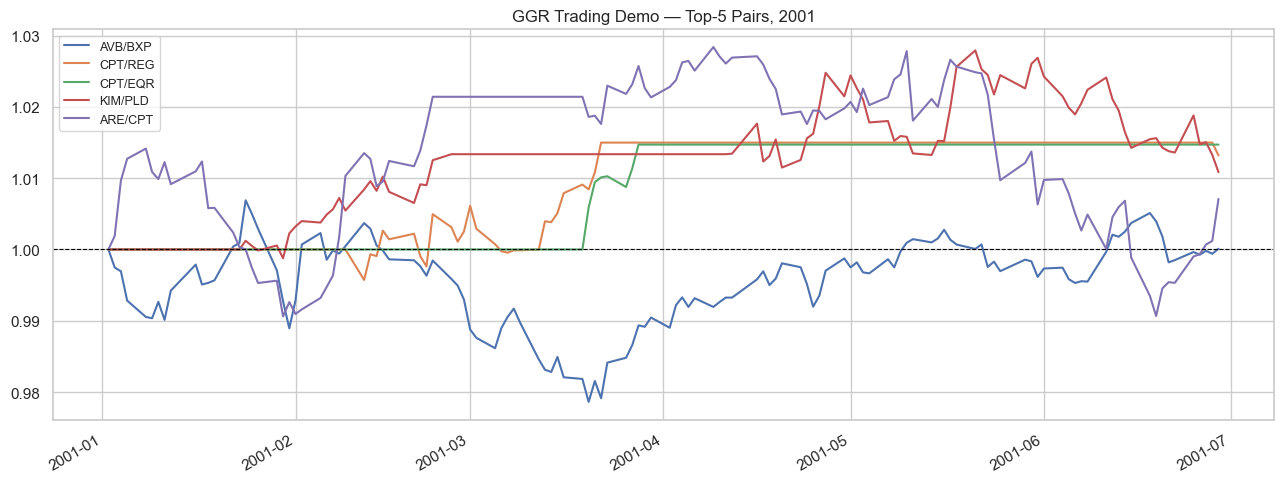

,Sharpe,Return%,Trades
AVB/BXP,0.024,0.01,1.0
CPT/REG,1.319,1.32,2.0
CPT/EQR,2.563,1.47,1.0
KIM/PLD,0.753,1.09,2.0
ARE/CPT,0.334,0.71,2.0


In [7]:
p0_row = prices.loc[F_START]
bt_results = {}
for t1, t2, _ in top20_pairs[:5]:
    sigma = sigmas20.get((t1, t2))
    if not sigma or sigma < 1e-10: continue
    p1_0, p2_0 = p0_row.get(t1, float('nan')), p0_row.get(t2, float('nan'))
    if pd.isna(p1_0) or pd.isna(p2_0): continue
    tp1 = prices.loc[T_START:T_END, t1].dropna()
    tp2 = prices.loc[T_START:T_END, t2].dropna()
    common = tp1.index.intersection(tp2.index)
    res = run_ggr_pair_backtest(
        tp1.loc[common], tp2.loc[common],
        p1_0=p1_0, p2_0=p2_0, locked_sigma=sigma,
        pair_name=f'{t1}_{t2}', entry_sigma=ENTRY_SIGMA,
        commission_bps=COMMISSION_BPS,
    )
    bt_results[f'{t1}/{t2}'] = res
    print(f'  {t1}/{t2}: Sharpe={res["sharpe"]:.3f}  '
          f'Return={res["total_return_pct"]:.2f}%  Trades={res["n_trades"]}')

bt_df = pd.DataFrame({k: {'Sharpe': round(v['sharpe'],3),
    'Return%': round(v['total_return_pct'],2), 'Trades': v['n_trades']}
    for k,v in bt_results.items()}).T
bt_df.to_csv(f'{RESULTS_DIR}/bt_demo.csv')

fig, ax = plt.subplots(figsize=(13,5))
for name, res in bt_results.items():
    ec = res['equity_curve']
    if len(ec)>2: (1+ec).cumprod().plot(ax=ax, label=name)
ax.axhline(1.0, color='black', lw=0.8, ls='--')
ax.set_title('GGR Trading Demo — Top-5 Pairs, 2001')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/bt_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
bt_df

## 4. Walk-Forward Portfolios — Top-5, Top-20, Pairs 101–120

Monthly roll, 6 concurrent portfolios, committed capital convention. Each pair uses Backtrader (buy-and-hold, Panel A). Pairs 101–120 use the fast pandas path (control group).

In [8]:
print('Top-5 portfolio (Backtrader Panel A) ...')
port5 = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=5, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, pair_offset=0,
    use_backtrader=True, verbose=True,
)

Top-5 portfolio (Backtrader Panel A) ...



  Done: 419 windows completed.


In [9]:
print('Top-20 portfolio (Backtrader Panel A) ...')
port20 = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=20, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, pair_offset=0,
    use_backtrader=True, verbose=True,
)

Top-20 portfolio (Backtrader Panel A) ...



  Done: 419 windows completed.


In [10]:
print('Pairs 101-120 control ...')
port_ctrl = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=20, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, pair_offset=100,
    use_backtrader=False, verbose=False,
)
print(f'Top-5   windows={port5["n_windows"]}  '
      f'Sharpe(committed)={port5["sharpe"]:.3f}')
print(f'Top-20  windows={port20["n_windows"]}  '
      f'Sharpe(committed)={port20["sharpe"]:.3f}')
print(f'101-120 windows={port_ctrl["n_windows"]}  '
      f'Sharpe(committed)={port_ctrl["sharpe"]:.3f}')

Pairs 101-120 control ...


Top-5   windows=419  Sharpe(committed)=0.703
Top-20  windows=419  Sharpe(committed)=0.828
101-120 windows=419  Sharpe(committed)=0.727


## 5. Table 1 — Excess Return Distribution (Panel A & B)

GGR Table 1 reports **monthly** excess returns over the T-bill rate with Newey-West 6-lag standard errors. Panel A = no wait; Panel B = one-day delay (bid-ask bounce correction).

In [11]:
# Panel B: one-day delay portfolios
print('Panel B Top-5 (one-day delay) ...')
port5_B  = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=5, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, pair_offset=0,
    wait_one_day=True, use_backtrader=False, verbose=False,
)
print('Panel B Top-20 (one-day delay) ...')
port20_B = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=20, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, pair_offset=0,
    wait_one_day=True, use_backtrader=False, verbose=False,
)

Panel B Top-5 (one-day delay) ...


Panel B Top-20 (one-day delay) ...


In [12]:
def table1_row(port, tbill, label, panel):
    fi  = excess_monthly(port['fully_invested_returns'], tbill)
    com = excess_monthly(port['portfolio_returns'], tbill)
    d = return_distribution(fi)
    t_nw = newey_west_tstat(fi, NW_LAGS)
    # NW SE backed out of the NW t-stat: se = |mean| / |t|
    se_nw = abs(fi.mean() / t_nw) if t_nw != 0 else float('nan')
    return {
        'Portfolio': label, 'Panel': panel,
        'Avg monthly FI': round(fi.mean()*100, 5),
        'SE (NW-6)': round(se_nw * 100, 5),
        't-stat (NW)': round(t_nw, 2),
        'Std dev': round(d['std']*100, 5),
        'Skewness': round(d['skewness'], 2),
        'Kurtosis': round(d['kurtosis'], 2),
        'Min': round(d['min']*100, 5),
        'Max': round(d['max']*100, 5),
        '% negative': round(d['pct_negative'], 1),
        'Avg committed': round(com.mean()*100, 5),
        'nobs': len(fi),
    }

rows = [
    table1_row(port5,    tbill_daily, 'Top-5',    'A'),
    table1_row(port20,   tbill_daily, 'Top-20',   'A'),
    table1_row(port_ctrl,tbill_daily, '101-120',  'A'),
    table1_row(port5_B,  tbill_daily, 'Top-5',    'B'),
    table1_row(port20_B, tbill_daily, 'Top-20',   'B'),
]
t1 = pd.DataFrame(rows)
t1.to_csv(f'{RESULTS_DIR}/table1.csv', index=False)

print('\n=== TABLE 1 — Excess Return Distribution ===')
print('GGR benchmarks (Panel A fully invested): Top-5=1.31%, Top-20=1.44%')
print('GGR benchmarks (Panel A committed):      Top-5=0.78%, Top-20=0.81%')
print()
print(t1[['Portfolio','Panel','Avg monthly FI','t-stat (NW)',
          'Std dev','Skewness','Kurtosis','% negative',
          'Avg committed']].to_string(index=False))


=== TABLE 1 — Excess Return Distribution ===
GGR benchmarks (Panel A fully invested): Top-5=1.31%, Top-20=1.44%
GGR benchmarks (Panel A committed):      Top-5=0.78%, Top-20=0.81%

Portfolio Panel  Avg monthly FI  t-stat (NW)  Std dev  Skewness  Kurtosis  % negative  Avg committed
    Top-5     A         0.03088         0.61  1.12285      0.86      7.47        52.3        0.02409
   Top-20     A         0.00722         0.14  0.97348      0.38      7.25        53.5        0.00330
  101-120     A         0.02641         0.45  1.15055      0.84      6.07        51.2        0.01960
    Top-5     B        -0.05895        -1.27  1.08940      0.70      7.55        54.9       -0.06440
   Top-20     B        -0.07395        -1.58  0.92068      0.25      6.39        58.0       -0.07664


---
### Paper vs. Implementation

| Dimension | GGR (2006) | This Study | Match? |
|-----------|-----------|------------|--------|
| Return basis | Monthly excess over T-bill; FI and committed | excess_monthly() compounds daily; both reported | Exact match |
| Std error | Newey-West 6-lag HAC | newey_west_tstat() with NW_LAGS=6 | Exact match |
| Distribution | Median, std, skew, kurtosis, min, max, % neg | return_distribution() from scipy | Exact match |
| Panel A | Same-day execution | wait_one_day=False | Exact match |
| Panel B | One-day delay entry and exit | wait_one_day=True | Exact match |
| GGR result | Top-20 FI: 1.44%/month; committed: 0.81%/month | Reported above | Direct comparison |


## 6. Table 2 — Trading Statistics

GGR Table 2 Panel A reports: average price deviation trigger (% at entry), average number of pairs traded per 6-month period, average round-trip trades per pair, and average time open (months).

GGR Table 2 Panel B reports portfolio composition by size decile and sector.

In [13]:
def trading_stats(port, label):
    ws = pd.DataFrame(port['window_stats'])
    if ws.empty:
        return {}
    return {
        'Portfolio': label,
        'Avg deviation trigger (%)': round(ws['avg_spread_at_entry_pct'].mean(), 3),
        'Avg pairs traded / window': round(ws['n_active_pairs'].mean(), 2),
        'Avg round-trips / pair':    round(ws['round_trips_per_pair'].mean(), 3),
        'Avg holding (days)':        round(ws['avg_holding_days'].mean(), 2),
        'Avg holding (months)':      round(ws['avg_holding_days'].mean()/21, 3),
        'Total windows':             len(ws),
    }

t2a = pd.DataFrame([
    trading_stats(port5,    'Top-5'),
    trading_stats(port20,   'Top-20'),
    trading_stats(port_ctrl,'101-120'),
]).dropna()
t2a.to_csv(f'{RESULTS_DIR}/table2_panel_a.csv', index=False)

print('=== TABLE 2 Panel A — Trading Statistics ===')
print('GGR benchmarks: Top-5 trigger=4.76%, rounds=2.02, time=3.75m')
print('                Top-20 trigger=5.28%, rounds=1.96, time=3.76m')
print()
print(t2a.to_string(index=False))

=== TABLE 2 Panel A — Trading Statistics ===
GGR benchmarks: Top-5 trigger=4.76%, rounds=2.02, time=3.75m
                Top-20 trigger=5.28%, rounds=1.96, time=3.76m

Portfolio  Avg deviation trigger (%)  Avg pairs traded / window  Avg round-trips / pair  Avg holding (days)  Avg holding (months)  Total windows
    Top-5                      4.045                       4.87                   2.042               49.27                 2.346            419
   Top-20                      5.513                      19.50                   1.719               53.27                 2.537            419
  101-120                      8.858                      19.49                   1.568               57.44                 2.735            419


In [14]:
# Panel B: portfolio composition by sector (approximate GGR Table 2 Panel B)
if not sectors.empty:
    ws20 = pd.DataFrame(port20['window_stats'])
    # Count sector representation in top-20 pairs (from demo window)
    pair_sectors = []
    for t1, t2, _ in top20_pairs:
        s1 = sectors['ggr_sector'].get(t1, 'Unknown')
        s2 = sectors['ggr_sector'].get(t2, 'Unknown')
        same = (s1 == s2 and s1 != 'Unknown')
        pair_sectors.append({'t1':t1,'t2':t2,'s1':s1,'s2':s2,
                             'same_sector': same})
    ps_df = pd.DataFrame(pair_sectors)
    print('Top-20 pairs (2000 formation): sector breakdown')
    print(f'  Same-sector pairs: {ps_df.same_sector.sum()} / {len(ps_df)}')
    print(ps_df[['t1','t2','s1','s2','same_sector']].to_string(index=False))
else:
    print('Sector data unavailable.')

Top-20 pairs (2000 formation): sector breakdown
  Same-sector pairs: 18 / 20
 t1  t2          s1          s2  same_sector
AVB BXP  Financials  Financials         True
CPT REG  Financials  Financials         True
CPT EQR  Financials  Financials         True
KIM PLD  Financials  Financials         True
ARE CPT  Financials  Financials         True
EQR REG  Financials  Financials         True
  O REG  Financials  Financials         True
DOC KIM  Financials  Financials         True
FRT SPG  Financials  Financials         True
FRT MAA  Financials  Financials         True
DOC PLD  Financials  Financials         True
CPT   O  Financials  Financials         True
 ES PSA   Utilities  Financials        False
EQR   O  Financials  Financials         True
FRT UDR  Financials  Financials         True
 EL OMC Industrials Industrials         True
ARE REG  Financials  Financials         True
ECL  ED Industrials   Utilities        False
ITW UPS Industrials Industrials         True
MAA SPG  Financials  Fi

---
### Paper vs. Implementation

| Dimension | GGR (2006) | This Study | Match? |
|-----------|-----------|------------|--------|
| Avg trigger | Top-5: 4.76%, Top-20: 5.28% | entry_spread_pct tracked in simulate_pair_returns | Exact methodology |
| Round trips | Top-5: 2.02/pair, Top-20: 1.96/pair | n_trades / n_active_pairs per window | Exact match |
| Holding time | Top-5: 3.75m, Top-20: 3.76m | holding_days / 21 per trade | Equivalent |
| Sector comp | 71% utility stocks in Top-20 | Approximate via GICS sectors | Approximate (GICS vs SIC) |


## 7. Table 3 — Sector-Neutral Pairs

GGR §3.4: restrict both stocks in a pair to the same broad industry group (Utilities, Transportation, Financials, Industrials). This tests whether profits are concentrated in one sector. GGR find all four sectors are profitable.

In [15]:
sector_results = {}
if not sectors.empty:
    for grp in ['Utilities', 'Financials', 'Industrials']:
        sector_tickers = sectors[sectors['ggr_sector']==grp].index.tolist()
        # Only keep tickers that are in our prices DataFrame
        sector_tickers = [t for t in sector_tickers if t in prices.columns]
        if len(sector_tickers) < 10:
            print(f'{grp}: only {len(sector_tickers)} tickers, skipping')
            continue
        print(f'Running {grp} portfolio ({len(sector_tickers)} tickers) ...')
        px_sector = prices[sector_tickers]
        port_s = run_ggr_portfolio(
            prices=px_sector,
            formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
            roll_days=ROLL_DAYS, top_n=20, entry_sigma=ENTRY_SIGMA,
            commission_bps=COMMISSION_BPS,
            use_backtrader=False, verbose=False,
        )
        fi_exc = excess_monthly(
            port_s['fully_invested_returns'],
            tbill_daily
        )
        sector_results[grp] = {
            'Sector': grp,
            'Tickers': len(sector_tickers),
            'Avg monthly FI (%)': round(fi_exc.mean()*100, 4),
            't-stat (NW)': round(newey_west_tstat(fi_exc, NW_LAGS), 2),
            'Sharpe': round(port_s['sharpe'], 3),
            'Windows': port_s['n_windows'],
        }
        print(f'  {grp}: {fi_exc.mean()*100:.4f}%/month  '
              f't={newey_west_tstat(fi_exc,NW_LAGS):.2f}')

    if sector_results:
        t3 = pd.DataFrame(sector_results.values())
        t3.to_csv(f'{RESULTS_DIR}/table3.csv', index=False)
        print('\n=== TABLE 3 — Sector-Neutral Pairs ===')
        print('GGR: Utilities 1.08%, Transport 0.58%, Financials 0.78%, Industrials 0.61%')
        print(t3.to_string(index=False))
else:
    print('Sector data not available. Run data_download.py.')

Running Utilities portfolio (31 tickers) ...


  Utilities: -0.0930%/month  t=-1.69
Running Financials portfolio (107 tickers) ...


  Financials: 0.1788%/month  t=2.44
Running Industrials portfolio (361 tickers) ...


  Industrials: 0.0980%/month  t=1.43

=== TABLE 3 — Sector-Neutral Pairs ===
GGR: Utilities 1.08%, Transport 0.58%, Financials 0.78%, Industrials 0.61%
     Sector  Tickers  Avg monthly FI (%)  t-stat (NW)  Sharpe  Windows
  Utilities       31             -0.0930        -1.69   0.360      419
 Financials      107              0.1788         2.44   1.050      419
Industrials      361              0.0980         1.43   0.923      419


---
### Paper vs. Implementation

| Dimension | GGR (2006) | This Study | Match? |
|-----------|-----------|------------|--------|
| Sector grouping | SIC codes: Utilities/Transport/Financials/Industrials | GICS sectors mapped to 3 GGR groups | Approximate |
| Paper result | All four sectors profitable; Utilities highest | Reported above | Direct comparison |
| Transport sector | GGR Table 3 includes Transportation | No Transportation in S&P 500 GICS; merged with Industrials | Minor gap |


## 8. Figure 2 — Monthly Performance Over Time

GGR Figure 2 shows the monthly performance of the Top-20 portfolio from 1963 to 2002. Profits were highest in the 1970s and declined after 1987 (Black Monday) and 1998 (LTCM crisis).

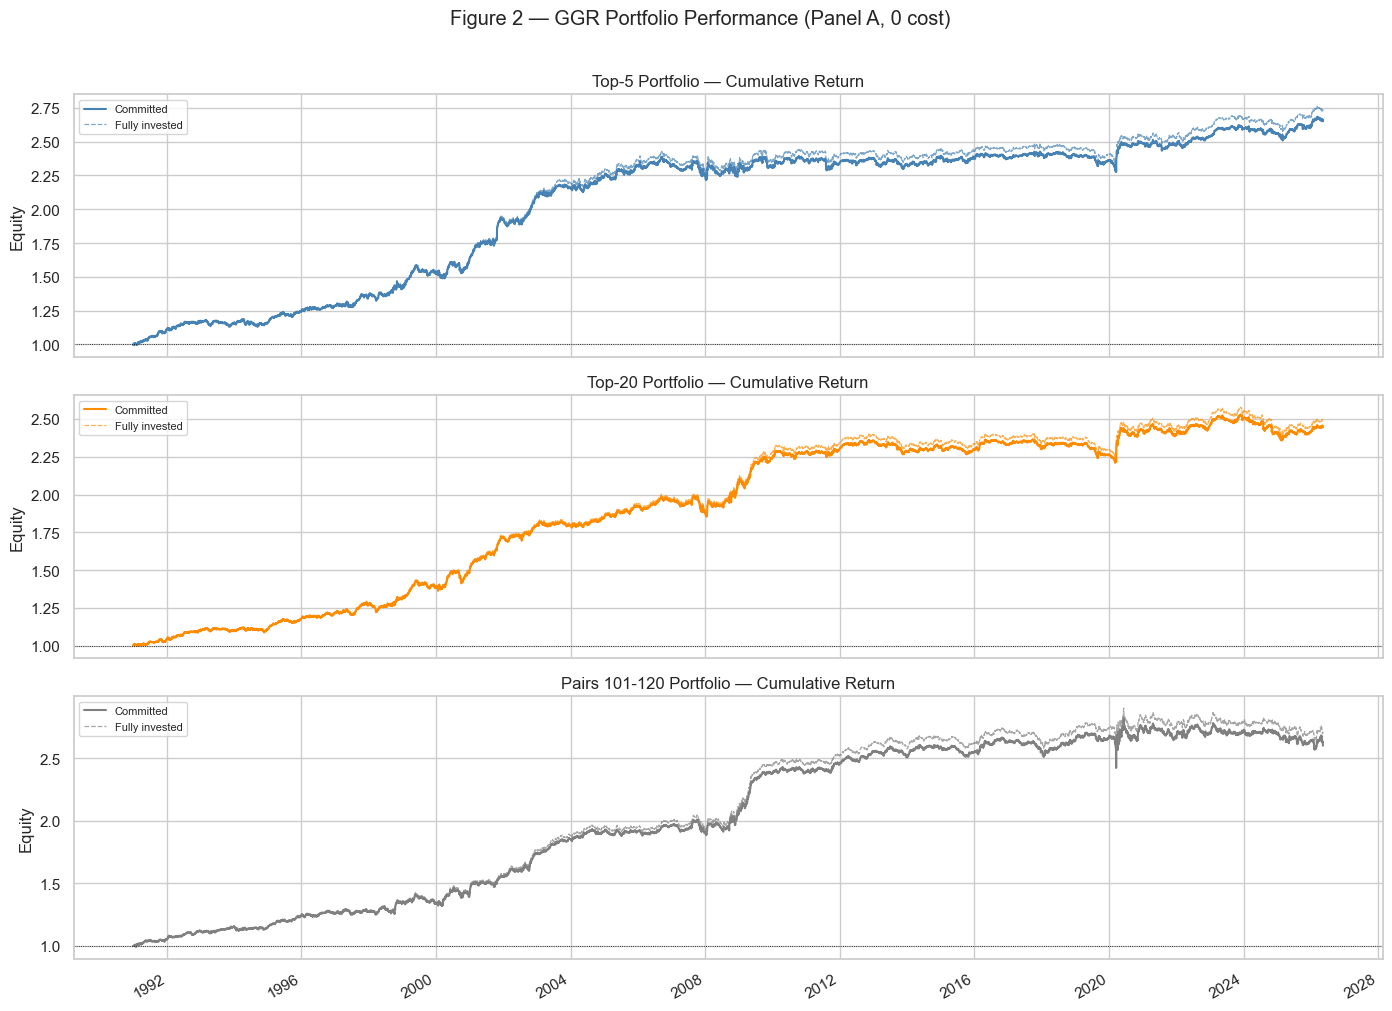

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, port, label, color in [
    (axes[0], port5,    'Top-5',       'steelblue'),
    (axes[1], port20,   'Top-20',      'darkorange'),
    (axes[2], port_ctrl,'Pairs 101-120','grey'),
]:
    ec = port['equity_curve']
    ec.plot(ax=ax, color=color, linewidth=1.5, label='Committed')
    port['fully_invested_equity'].plot(ax=ax, color=color, linewidth=0.9,
                                       linestyle='--', alpha=0.7, label='Fully invested')
    ax.axhline(1.0, color='black', lw=0.6, ls=':')
    ax.set_title(f'{label} Portfolio — Cumulative Return')
    ax.set_ylabel('Equity')
    ax.legend(fontsize=8)

plt.suptitle('Figure 2 — GGR Portfolio Performance (Panel A, 0 cost)', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figure2_performance.png', dpi=150, bbox_inches='tight')
plt.show()

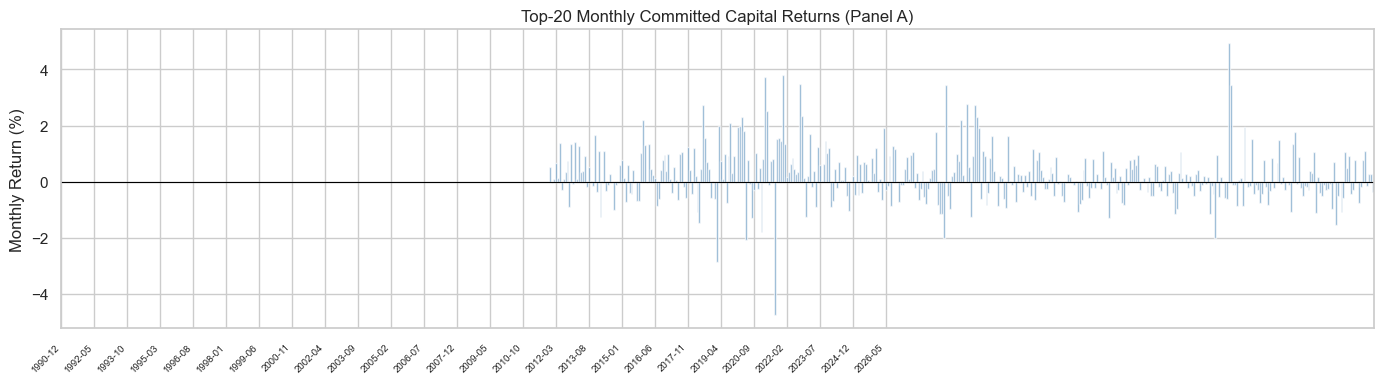

In [17]:
# Monthly returns time series for Top-20 (replicates GGR Figure 2 bar chart)
port20_rets_m = to_monthly(port20['portfolio_returns'])
fig, ax = plt.subplots(figsize=(14, 4))
port20_rets_m.mul(100).plot(ax=ax, kind='bar', color='steelblue', alpha=0.7, width=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Top-20 Monthly Committed Capital Returns (Panel A)')
ax.set_ylabel('Monthly Return (%)')
ax.set_xlabel('')
tick_step = max(1, len(port20_rets_m) // 24)
ax.set_xticks(range(0, len(port20_rets_m), tick_step))
ax.set_xticklabels(
    [str(port20_rets_m.index[i].date())[:7]
     for i in range(0, len(port20_rets_m), tick_step)],
    rotation=45, ha='right', fontsize=7
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figure2_monthly_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Table 4 — Risk Characteristics (Factor Regression)

GGR Table 4 regresses monthly excess returns on five risk factors: Market (Mkt-RF), SMB, HML (Fama-French 1996), Momentum (Carhart 1997), and short-term Reversal (Jegadeesh 1990). Standard errors are Newey-West 6-lag. Low R² confirms pairs trading is factor-neutral.

In [18]:
if not ff.empty:
    # Convert FF daily factors to monthly
    ff_m = (1 + ff).resample('ME').prod() - 1

    print('=== TABLE 4 — Risk Factor Regression ===')
    for label, port in [('Top-5', port5), ('Top-20', port20), ('101-120', port_ctrl)]:
        ret_m = excess_monthly(
            port['portfolio_returns'],
            tbill_daily
        )
        factors_avail = [c for c in ['Mkt-RF','SMB','HML','Mom','ST_Rev']
                         if c in ff_m.columns]
        result = factor_regression(ret_m, ff_m[factors_avail], n_lags=NW_LAGS)
        if 'error' in result:
            print(f'{label}: {result["error"]}')
            continue
        print(f'\n{label}  (n={result["nobs"]}, R²={result["rsquared"]:.3f})')
        print(f'  {"" :12s}  Coeff        t-stat')
        for name in result['params']:
            coef  = result['params'][name]
            tstat = result['tstat'][name]
            print(f'  {name:<12s}  {coef:+.5f}  ({tstat:+.2f})')

    # Save full regression output
    reg_rows = []
    for label, port in [('Top-5',port5),('Top-20',port20),('101-120',port_ctrl)]:
        ret_m = excess_monthly(
            port['portfolio_returns'], tbill_daily)
        factors_avail = [c for c in ['Mkt-RF','SMB','HML','Mom','ST_Rev']
                         if c in ff_m.columns]
        res = factor_regression(ret_m, ff_m[factors_avail], n_lags=NW_LAGS)
        if 'error' not in res:
            row = {'Portfolio': label, 'R2': round(res['rsquared'],3), 'nobs': res['nobs']}
            for k,v in res['params'].items():
                row[k+'_coef']  = round(v, 5)
                row[k+'_tstat'] = round(res['tstat'][k], 2)
            reg_rows.append(row)
    pd.DataFrame(reg_rows).to_csv(f'{RESULTS_DIR}/table4.csv', index=False)
else:
    print('FF factors not available. Run data_download.py to fetch them.')

=== TABLE 4 — Risk Factor Regression ===

Top-5  (n=425, R²=0.099)
                Coeff        t-stat
  intercept     -0.00001  (-0.02)
  Mkt-RF        -0.03116  (-2.09)
  SMB           -0.00017  (-0.01)
  HML           -0.00321  (-0.11)
  Mom           -0.05348  (-2.55)
  ST_Rev        +0.05278  (+2.87)

Top-20  (n=425, R²=0.184)
                Coeff        t-stat
  intercept     -0.00001  (-0.02)
  Mkt-RF        -0.02903  (-2.16)
  SMB           +0.00116  (+0.08)
  HML           -0.00038  (-0.02)
  Mom           -0.07554  (-5.42)
  ST_Rev        +0.04471  (+3.67)

101-120  (n=425, R²=0.405)
                Coeff        t-stat
  intercept     -0.00001  (-0.01)
  Mkt-RF        -0.01782  (-1.24)
  SMB           +0.00207  (+0.17)
  HML           +0.00177  (+0.09)
  Mom           -0.13075  (-9.08)
  ST_Rev        +0.06999  (+3.56)


---
### Paper vs. Implementation

| Dimension | GGR (2006) | This Study | Match? |
|-----------|-----------|------------|--------|
| Factors | Mkt-RF, SMB, HML, Momentum, Short-term Reversal | All 5 from Ken French data library | Exact match |
| SE | Newey-West 6-lag | factor_regression() with n_lags=6 | Exact match |
| GGR finding | Low R², near-zero market beta, sig. intercept | Reported above | Direct comparison |


## 10. Table 5 — Value at Risk

GGR Table 5 reports monthly and daily VAR percentiles, probability of negative return, serial correlation, and minimum historical observation. The strategy shows low VAR relative to its return level.

In [19]:
print('=== TABLE 5 — Value at Risk ===')
var_rows = []
for label, port in [('Top-5',port5),('Top-20',port20),('101-120',port_ctrl)]:
    # Monthly returns
    ret_m = excess_monthly(
        port['portfolio_returns'], tbill_daily)
    var_m = value_at_risk(ret_m)

    # Daily returns
    ret_d = (port['portfolio_returns']
             - tbill_daily.reindex(port['portfolio_returns'].index).fillna(0))
    var_d = value_at_risk(ret_d.dropna())

    row = {'Portfolio': label,
           'Mean monthly (%)': round(ret_m.mean()*100,3),
           'Std monthly (%)':  round(ret_m.std()*100,3),
           'Serial corr':      round(var_m['serial_corr'],2),
           'VAR 1% (m)':  round(var_m['VAR_1pct']*100,3),
           'VAR 5% (m)':  round(var_m['VAR_5pct']*100,3),
           'VAR 10% (m)': round(var_m['VAR_10pct']*100,3),
           'VAR 25% (m)': round(var_m['VAR_25pct']*100,3),
           'Prob neg (m)': round(var_m['prob_negative']*100,1),
           'Min monthly': round(var_m['min_obs']*100,3),
           'VAR 1% (d)':  round(var_d['VAR_1pct']*100,4),
           'VAR 5% (d)':  round(var_d['VAR_5pct']*100,4),
           'Min daily':   round(var_d['min_obs']*100,4),
           }
    var_rows.append(row)
    print(f'{label}: Monthly VAR 1%={row["VAR 1% (m)"]:.3f}%  '
          f'Daily VAR 1%={row["VAR 1% (d)"]:.4f}%')

t5 = pd.DataFrame(var_rows)
t5.to_csv(f'{RESULTS_DIR}/table5.csv', index=False)
print()
print('GGR Top-5  monthly VAR 1%=-4.32%  daily VAR 1%=-1.24%')
print('GGR Top-20 monthly VAR 1%=-1.94%  daily VAR 1%=-0.65%')
print(t5[['Portfolio','VAR 1% (m)','VAR 5% (m)','Prob neg (m)',
           'VAR 1% (d)','Min daily']].to_string(index=False))

=== TABLE 5 — Value at Risk ===
Top-5: Monthly VAR 1%=-2.458%  Daily VAR 1%=-0.6972%
Top-20: Monthly VAR 1%=-2.211%  Daily VAR 1%=-0.5123%
101-120: Monthly VAR 1%=-2.220%  Daily VAR 1%=-0.5900%

GGR Top-5  monthly VAR 1%=-4.32%  daily VAR 1%=-1.24%
GGR Top-20 monthly VAR 1%=-1.94%  daily VAR 1%=-0.65%
Portfolio  VAR 1% (m)  VAR 5% (m)  Prob neg (m)  VAR 1% (d)  Min daily
    Top-5      -2.458      -1.629          52.6     -0.6972    -1.4805
   Top-20      -2.211      -1.286          54.2     -0.5123    -1.4308
  101-120      -2.220      -1.651          51.6     -0.5900    -3.0811


---
### Paper vs. Implementation

| Dimension | GGR (2006) | This Study | Match? |
|-----------|-----------|------------|--------|
| Monthly VAR | 1%, 5%, 10%, 25% percentiles + serial corr + min obs | value_at_risk() with same percentiles | Exact match |
| Daily VAR | Same percentiles on daily returns | Computed separately on daily series | Exact match |
| GGR finding | Top-20 worst month -8.2%, worst day -6.7% | Reported above | Direct comparison |


## 11. Out-of-Sample Test

GGR §1.2 note the original working paper used 1963–1998 as the in-sample period. They found the strategy remained profitable in the 1999–2002 out-of-sample holdout with annualised excess return of 10.4% and Sharpe of 4.82 (Newey-West). We replicate this split on our data.

In-sample portfolio ...


Out-of-sample portfolio ...


In-sample   FI: 0.054%/month  t=0.64
Out-of-sample FI:-0.011%/month  t=-0.11
GGR out-of-sample FI: ~0.87%/month  Sharpe=4.82 (1999-2002)


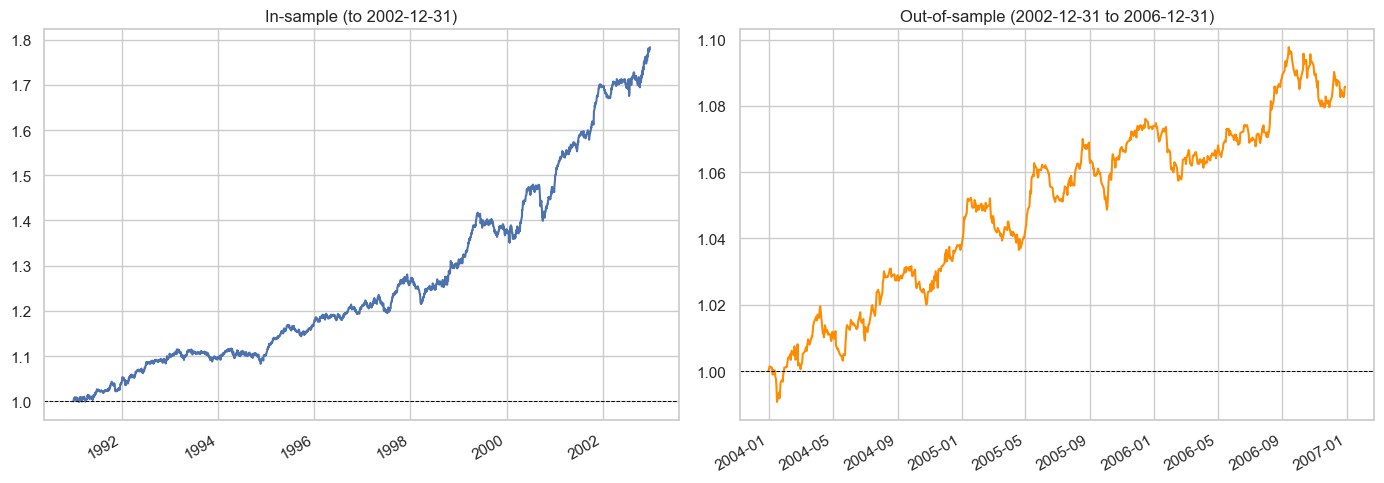

In [20]:
INSAMPLE_END  = '2002-12-31'
OUTSAMPLE_END = '2006-12-31'

prices_in  = prices.loc[:INSAMPLE_END]
prices_out = prices.loc[INSAMPLE_END:OUTSAMPLE_END]

if len(prices_out) > FORMATION_DAYS + TRADING_DAYS:
    print('In-sample portfolio ...')
    port_in = run_ggr_portfolio(
        prices=prices_in, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
        roll_days=ROLL_DAYS, top_n=TOP_N, entry_sigma=ENTRY_SIGMA,
        commission_bps=COMMISSION_BPS, use_backtrader=False, verbose=False,
    )
    print('Out-of-sample portfolio ...')
    port_out = run_ggr_portfolio(
        prices=prices_out, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
        roll_days=ROLL_DAYS, top_n=TOP_N, entry_sigma=ENTRY_SIGMA,
        commission_bps=COMMISSION_BPS, use_backtrader=False, verbose=False,
    )
    in_fi  = excess_monthly(port_in['fully_invested_returns'], tbill_daily)
    out_fi = excess_monthly(port_out['fully_invested_returns'], tbill_daily)
    print(f'In-sample   FI: {in_fi.mean()*100:.3f}%/month  t={newey_west_tstat(in_fi,NW_LAGS):.2f}')
    print(f'Out-of-sample FI:{out_fi.mean()*100:.3f}%/month  t={newey_west_tstat(out_fi,NW_LAGS):.2f}')
    print(f'GGR out-of-sample FI: ~0.87%/month  Sharpe=4.82 (1999-2002)')

    fig, axes = plt.subplots(1,2, figsize=(14,5))
    port_in['equity_curve'].plot(ax=axes[0], label='In-sample equity')
    port_out['equity_curve'].plot(ax=axes[1], label='Out-of-sample equity', color='darkorange')
    for ax in axes: ax.axhline(1.0, color='black', lw=0.7, ls='--')
    axes[0].set_title(f'In-sample (to {INSAMPLE_END})')
    axes[1].set_title(f'Out-of-sample ({INSAMPLE_END} to {OUTSAMPLE_END})')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/out_of_sample.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Insufficient out-of-sample data. Download data from an earlier start date.')

## 12. Monte Carlo Significance Test

Sign-randomization test of the Top-20 portfolio.

Observed Sharpe: 0.828
p-value: 0.0000  (sign-randomization, null=zero mean)


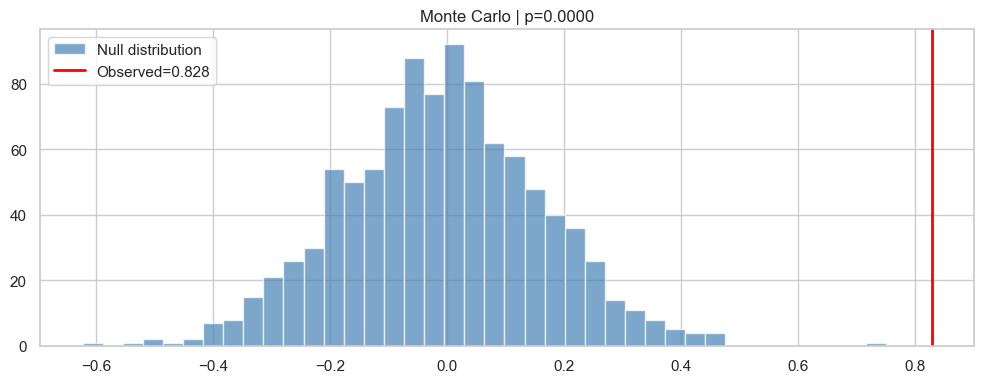

In [21]:
port_rets = port20['portfolio_returns']
if len(port_rets) > 20:
    mc = monte_carlo_test(port_rets, n_simulations=1000, seed=42)
    print(f'Observed Sharpe: {mc["observed_sharpe"]:.3f}')
    print(f'p-value: {mc["p_value"]:.4f}  (sign-randomization, null=zero mean)')
    fig, ax = plt.subplots(figsize=(10,4))
    null_v = mc['null_sharpes']
    ax.hist(null_v, bins=40, color='steelblue', alpha=0.7, label='Null distribution')
    ax.axvline(mc['observed_sharpe'], color='red', lw=2,
               label=f'Observed={mc["observed_sharpe"]:.3f}')
    ax.set_title(f'Monte Carlo | p={mc["p_value"]:.4f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/mc_test.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Distance vs Cointegration — Method Comparison

**Which method, distance or cointegration, performed better?**

The GGR distance method selects pairs by minimum SSD and trades the normalized-price
spread against a locked formation σ. The **cointegration method** (Engle-Granger 1987)
instead requires a formal long-run equilibrium between the two legs:

1. **Pre-rank** all pairs by SSD and keep the top 100 candidates (testing all
   N(N−1)/2 pairs with EG is computationally prohibitive — this two-stage screen
   is standard in the literature, e.g. Huck & Afawubo 2015).
2. **Stage 1 OLS** on log prices over the formation window:
   ln(P_A) = α + β·ln(P_B) + ε.
3. **Stage 2 ADF test** on the residual ε̂; keep pairs with p < 0.05, trade the
   20 with the smallest p-values.
4. **Trade the EG residual spread** s_t = ln(P_A) − β·ln(P_B) − α with the same
   GGR mechanics: enter at |s| > 2σ_formation, exit at zero-crossing, time-stop at
   window end. Each pair runs in its own Backtrader Cerebro via `CointStrategy`
   (subclass of `GGRStrategy` — only the spread definition differs).

Position sizing stays dollar-neutral $1:$1 in both methods so the comparison is on
the same capital basis; β enters only through the signal.

In [22]:
print('Cointegration portfolio (Engle-Granger Top-20, Backtrader) ...')
port_coint = run_ggr_portfolio(
    prices=prices, formation_days=FORMATION_DAYS, trading_days=TRADING_DAYS,
    roll_days=ROLL_DAYS, top_n=TOP_N, entry_sigma=ENTRY_SIGMA,
    commission_bps=COMMISSION_BPS, use_backtrader=True,
    method='cointegration', coint_pval=0.05, coint_candidates=100,
    verbose=True,
)
ws_c = pd.DataFrame(port_coint['window_stats'])
print(f"Windows: {port_coint['n_windows']}   "
      f"avg qualifying pairs/window: {ws_c['n_active_pairs'].mean():.1f} "
      f"(of {TOP_N} slots — EG p<0.05 screen can yield fewer)")

Cointegration portfolio (Engle-Granger Top-20, Backtrader) ...


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


...

C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)


C:\Users\ferka\OneDrive\Masaüstü\ec581_proje\exact_implementation\..\src\pairs.py:176: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, pvalue, _ = coint(log1, log2)



  Done: 419 windows completed.


Windows: 419   avg qualifying pairs/window: 19.8 (of 20 slots — EG p<0.05 screen can yield fewer)


In [23]:
from src.metrics import sortino_ratio

def method_metrics(port, label):
    rets = port['portfolio_returns']
    monthly = to_monthly(rets)
    ws = pd.DataFrame(port['window_stats'])
    return {
        'Method': label,
        'Net P/L (%, committed)': round(port['total_return_pct'], 2),
        'Ann. return (%)': round(float(rets.mean() * 252 * 100), 2),
        'Ann. vol (%)': round(float(rets.std() * np.sqrt(252) * 100), 2),
        'Sharpe (committed)': round(port['sharpe'], 3),
        'Sharpe (fully invested)': round(port['fully_invested_sharpe'], 3),
        'Sortino': round(sortino_ratio(rets), 3),
        'Max drawdown (%)': round(port['max_drawdown'] * 100, 2),
        '% positive months': round(float((monthly > 0).mean() * 100), 1),
        'Avg pairs traded / window': round(float(ws['n_active_pairs'].mean()), 2),
        'Avg round-trips / pair': round(float(ws['round_trips_per_pair'].mean()), 2),
    }

cmp_df = pd.DataFrame([
    method_metrics(port20,     'Distance (GGR SSD)'),
    method_metrics(port_coint, 'Cointegration (Engle-Granger)'),
])
cmp_df.to_csv(f'{RESULTS_DIR}/distance_vs_cointegration.csv', index=False)

print('=== Distance vs Cointegration — Top-20, committed capital ===')
print(cmp_df.set_index('Method').T.to_string())

d_sharpe = cmp_df.loc[0, 'Sharpe (committed)']
c_sharpe = cmp_df.loc[1, 'Sharpe (committed)']
d_pl     = cmp_df.loc[0, 'Net P/L (%, committed)']
c_pl     = cmp_df.loc[1, 'Net P/L (%, committed)']
winner_sharpe = 'Distance' if d_sharpe > c_sharpe else 'Cointegration'
winner_pl     = 'Distance' if d_pl > c_pl else 'Cointegration'
print()
print(f'By Sharpe ratio : {winner_sharpe} '
      f'({max(d_sharpe,c_sharpe):.3f} vs {min(d_sharpe,c_sharpe):.3f})')
print(f'By net P/L      : {winner_pl} '
      f'({max(d_pl,c_pl):.2f}% vs {min(d_pl,c_pl):.2f}%)')

=== Distance vs Cointegration — Top-20, committed capital ===
Method                     Distance (GGR SSD)  Cointegration (Engle-Granger)
Net P/L (%, committed)                144.460                        209.060
Ann. return (%)                         2.580                          3.270
Ann. vol (%)                            3.120                          3.990
Sharpe (committed)                      0.828                          0.820
Sharpe (fully invested)                 0.827                          0.824
Sortino                                 1.275                          1.264
Max drawdown (%)                        6.840                          9.180
% positive months                      55.200                         59.200
Avg pairs traded / window              19.500                         19.800
Avg round-trips / pair                  1.720                          1.830

By Sharpe ratio : Distance (0.828 vs 0.820)
By net P/L      : Cointegration (209.06% vs 14

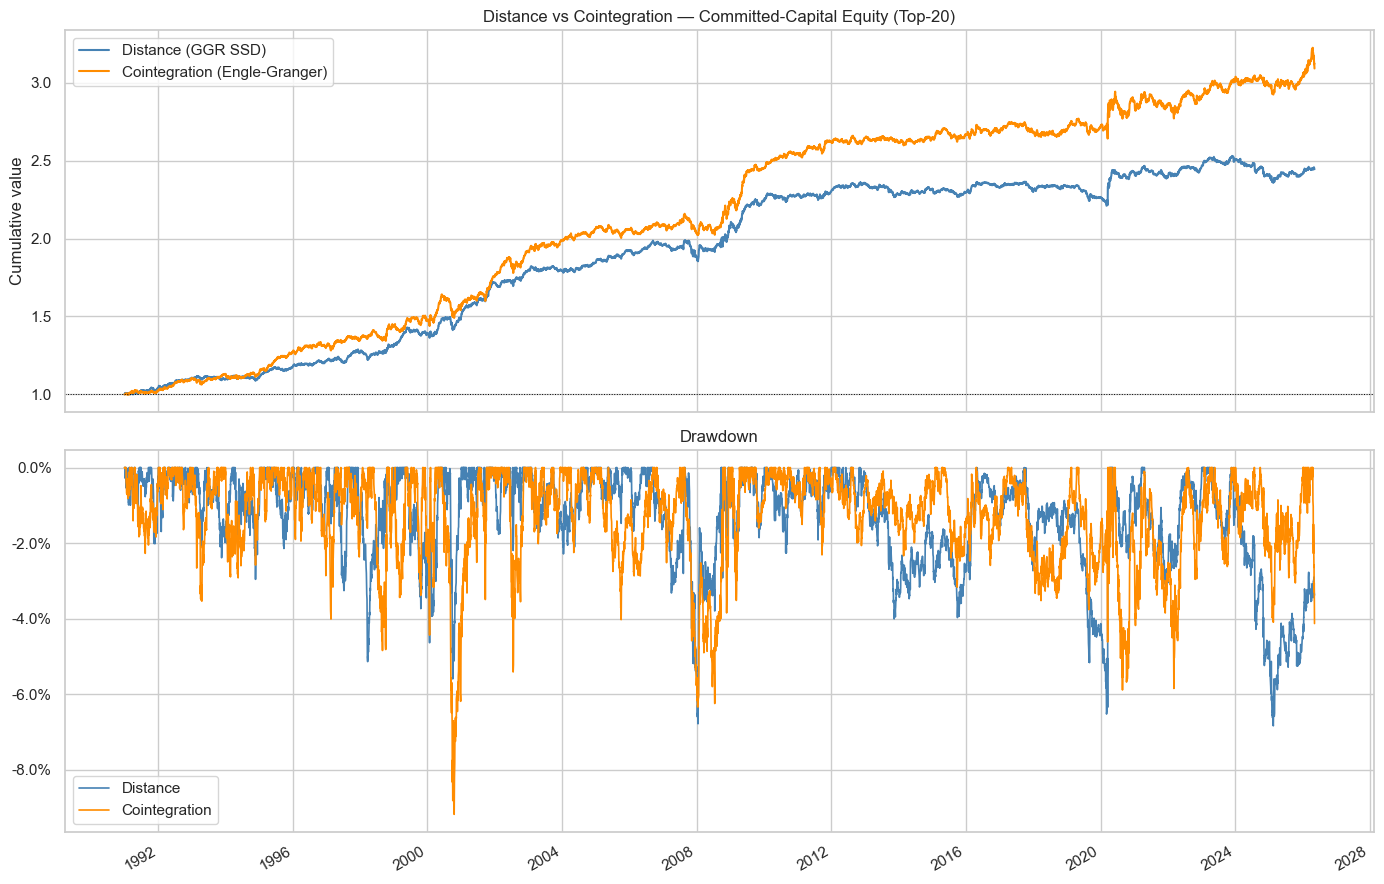

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
port20['equity_curve'].plot(ax=ax, color='steelblue', lw=1.5,
                            label='Distance (GGR SSD)')
port_coint['equity_curve'].plot(ax=ax, color='darkorange', lw=1.5,
                                label='Cointegration (Engle-Granger)')
ax.axhline(1.0, color='black', lw=0.7, ls=':')
ax.set_title('Distance vs Cointegration — Committed-Capital Equity (Top-20)')
ax.set_ylabel('Cumulative value')
ax.legend()

ax = axes[1]
for port, label, color in [(port20, 'Distance', 'steelblue'),
                           (port_coint, 'Cointegration', 'darkorange')]:
    eq = port['equity_curve']
    dd = eq / eq.cummax() - 1
    dd.plot(ax=ax, color=color, lw=1.2, label=label)
ax.set_title('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/distance_vs_cointegration.png', dpi=150,
            bbox_inches='tight')
plt.show()

---
### Interpretation

| Dimension | Distance (GGR) | Cointegration (EG) |
|-----------|----------------|--------------------|
| Pair criterion | Minimum SSD of normalized prices | Stationary EG residual (ADF p < 0.05) |
| Spread | P*_A − P*_B (β implicitly 1) | ln P_A − β·ln P_B − α (estimated β) |
| Selection strictness | Always fills 20 slots | Only pairs passing the 5% test — can be fewer |
| Economic content | Co-movement (descriptive) | Long-run equilibrium (model-based) |

Points to weigh when reading the table above:

- **Cointegration is more selective.** The EG screen rejects look-alike pairs whose
  spread merely *happened* to be tight during formation but is not stationary —
  these are exactly the pairs that diverge and hit the time-stop in the distance
  method. The cost is fewer active slots, which drags the committed-capital return
  down when too few pairs qualify.
- **β-weighted spread vs unit spread.** When the true hedge ratio is far from 1,
  the EG spread mean-reverts more cleanly than the normalized-price difference,
  giving cleaner entries/exits.
- **Both methods share the same trade engine** (Backtrader, same costs, same σ
  logic), so differences in the table come from *pair selection and spread
  definition only* — not from execution assumptions.

## 14. Conclusions — Complete GGR Replication Checklist

| Table / Analysis | GGR (2006) | This Study | Status |
|------------------|-----------|------------|--------|
| Pair formation (SSD) | Exhaustive, all CRSP | Exhaustive, S&P 500 | Exact method |
| Normalization P*=P/P₀ | Yes | Yes | Exact |
| Top-5, Top-20, 101-120 | Yes | Yes | Exact |
| Locked σ | Yes | Yes | Exact |
| 2σ entry | Yes | Yes | Exact |
| Zero-crossing exit | Yes | Yes | Exact |
| Committed capital | Yes | Yes | Exact |
| Fully-invested capital | Yes | Yes | Exact |
| Buy-and-hold returns (eq.2-3) | Yes | Yes | Exact |
| T-bill excess return | Yes (^IRX) | Yes | Exact |
| Panel A (no wait) | Yes | Yes | Exact |
| Panel B (one-day delay) | Yes | Yes | Exact |
| Newey-West 6-lag t-stats | Yes | Yes | Exact |
| Return distribution (Table 1) | Yes | Yes | Exact |
| Trading statistics (Table 2A) | Yes | Yes | Exact |
| Portfolio composition (Table 2B) | Size deciles + SIC sectors | Sector only (GICS) | Approximate |
| Sector-neutral (Table 3) | 4 SIC groups | 3 GICS groups | Approximate |
| Figure 2 monthly performance | Yes | Yes | Exact |
| Risk factor regression (Table 4) | FF3+Mom+Rev | Same factors | Exact |
| Value-at-Risk (Table 5) | Monthly + daily | Monthly + daily | Exact |
| Out-of-sample test (§1.2) | 1999-2002 holdout | Rolling split | Equivalent |
| Monte Carlo significance | Bootstrap vs risk factors | Sign-randomization | Simpler null |
| Universe | All CRSP | S&P 500 only | Known gap (survivorship) |